# Test Notebook for Game-Theoretic Empathic Environment

This notebook contains tests and visualizations for the game-theoretic multi-agent environment
where agents decide whether to exploit a shared resource pool, with optional empathic reward shaping.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join('..', 'game_theoretic_setup')))

from env_game_theoretic import GameTheoreticEnv
from agent_policies_game_theoretic import QAgent, DQNAgent, SocialRewardCalculator

np.random.seed(42)

## Test 1: Single-Step Environment Test

Initialize the environment, inspect basic properties, and verify the reset state.

In [3]:
NB_AGENTS = 6
INITIAL_RESOURCES = 30

env = GameTheoreticEnv(
    nb_agents=NB_AGENTS,
    initial_resources=INITIAL_RESOURCES,
    env_type='deterministic',
    emotion_type='average',
    see_emotions=True,
    alpha=0.5,
    beta=0.5,
    agent_class=DQNAgent,
    agent_configs=[{
        'learning_rate': 0.001,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_decay': 0.995,
        'epsilon_min': 0.01,
        'batch_size': 16,
        'hidden_size': 64,
        'update_target_every': 5
    } for _ in range(NB_AGENTS)],
    smoothing='linear',
    threshold=0.5
)

obs = env.reset()

print(f'Number of agents: {env.nb_agents}')
print(f'Initial resources: {env.initial_resources}')
print(f'Current resources: {env.resource}')
print(f'State size: {env.state_size}')
print(f'Number of actions: {env.n_actions}')
print(f'Environment type: {env.env_type}')
print(f'Alpha (empathy weight): {env.alpha}')
print(f'Emotion type: {env.emotion_type}')
print(f'See emotions: {env.see_emotions}')
print()
print('Initial observations:')
for i, o in enumerate(obs):
    print(f'  Agent {i}: {o} (shape={o.shape})')

Number of agents: 6
Initial resources: 30
Current resources: 30
State size: 1
Number of actions: 2
Environment type: deterministic
Alpha (empathy weight): 0.5
Emotion type: average
See emotions: True

Initial observations:
  Agent 0: [-1.] (shape=(1,))
  Agent 1: [-1.] (shape=(1,))
  Agent 2: [-1.] (shape=(1,))
  Agent 3: [-1.] (shape=(1,))
  Agent 4: [-1.] (shape=(1,))
  Agent 5: [-1.] (shape=(1,))


## Test 2: Agent Action Selection and Stepping

Run a few manual steps to inspect actions, rewards, emotions, and resource dynamics.

In [4]:
obs = env.reset()

print('Running 10 manual steps...\n')
for step in range(10):
    actions = [agent.select_action(obs[i]) for i, agent in enumerate(env.agents)]
    next_obs, rewards, done, info = env.step(actions)

    print(f'Step {step + 1}:')
    print(f'  Actions: {actions}')
    print(f'  Resource remaining: {env.resource:.1f}')
    print(f'  Emotions: {[f"{e:.3f}" for e in info["emotions"]]}')
    print(f'  Personal rewards: {[f"{r:.3f}" for r in info["personal_reward"]]}')
    print(f'  Empathic rewards: {[f"{r:.3f}" for r in info["empathic_reward"]]}')
    print(f'  Combined rewards: {[f"{r:.3f}" for r in info["combined_reward"]]}')
    print(f'  Done: {done}')
    print()

    for i, agent in enumerate(env.agents):
        agent.step(next_state=next_obs[i], reward=rewards[i], done=done)

    obs = next_obs
    if done:
        print('Resources depleted!')
        break

Running 10 manual steps...

Step 1:
  Actions: [0, 1, 0, 0, 1, 1]
  Resource remaining: 27.0
  Emotions: ['-1.000', '-0.800', '-1.000', '-1.000', '-0.800', '-0.800']
  Personal rewards: ['0.000', '0.550', '0.000', '0.000', '0.550', '0.550']
  Empathic rewards: ['-0.880', '-0.920', '-0.880', '-0.880', '-0.920', '-0.920']
  Combined rewards: ['-0.440', '-0.185', '-0.440', '-0.440', '-0.185', '-0.185']
  Done: False

Step 2:
  Actions: [0, 0, 1, 0, 0, 1]
  Resource remaining: 25.0
  Emotions: ['-1.000', '-0.800', '-0.800', '-1.000', '-0.800', '-0.600']
  Personal rewards: ['0.000', '0.050', '0.550', '0.000', '0.050', '0.600']
  Empathic rewards: ['-0.800', '-0.840', '-0.840', '-0.800', '-0.840', '-0.880']
  Combined rewards: ['-0.400', '-0.395', '-0.145', '-0.400', '-0.395', '-0.140']
  Done: False

Step 3:
  Actions: [0, 1, 0, 1, 1, 1]
  Resource remaining: 21.0
  Emotions: ['-1.000', '-0.600', '-0.800', '-0.800', '-0.600', '-0.400']
  Personal rewards: ['0.000', '0.600', '0.050', '0.550

## Test 3: Multi-Agent Simulation Over Several Episodes

Run a short training loop and plot learning curves for resource depletion and rewards.

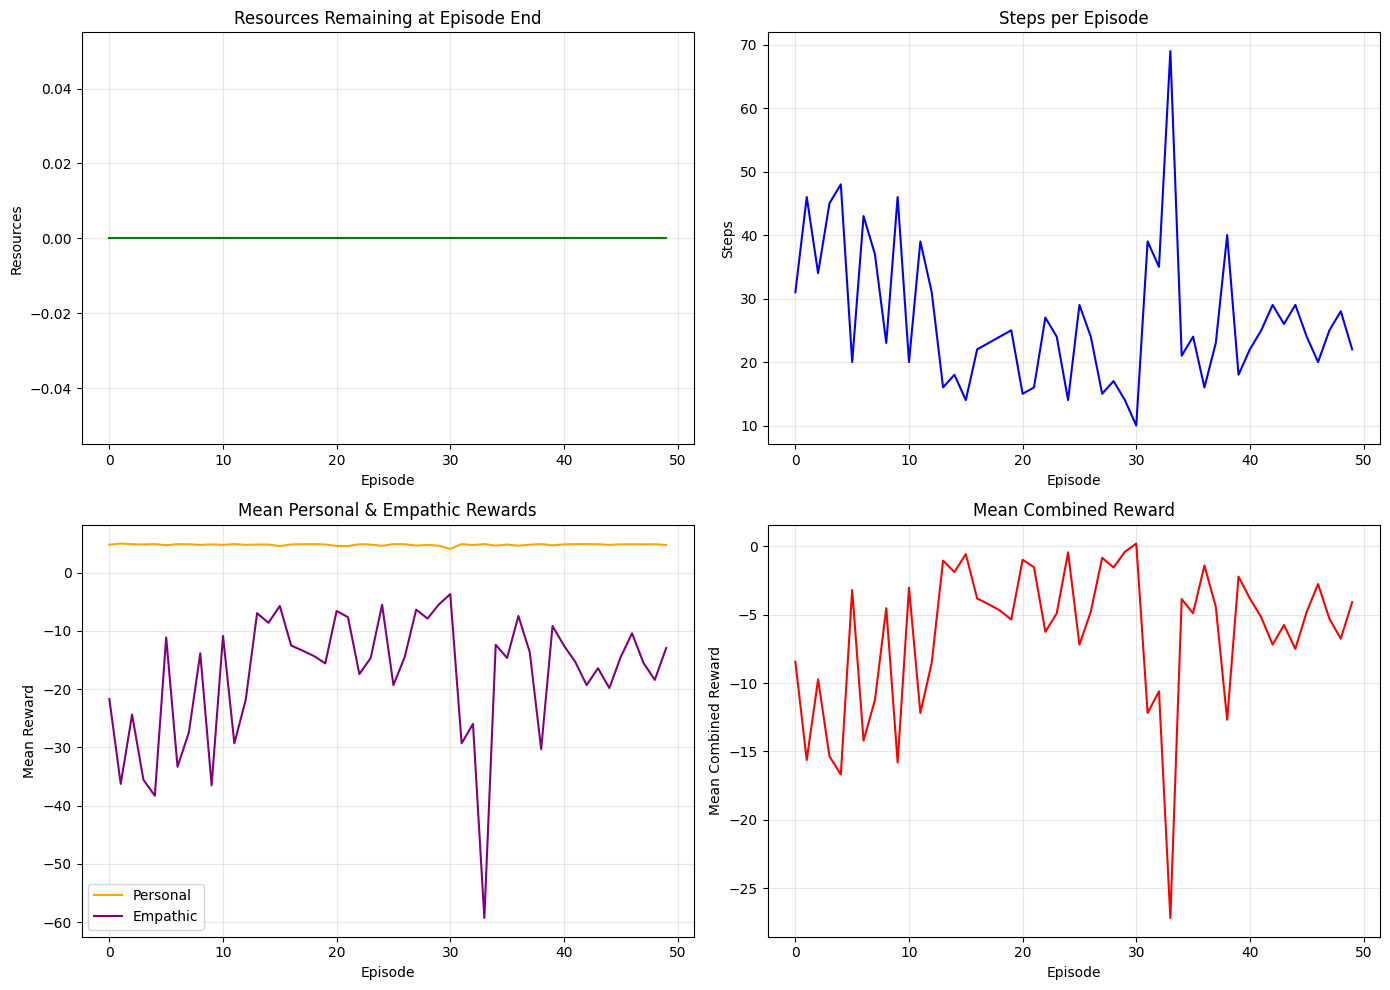

In [5]:
NUM_EPISODES = 50
MAX_STEPS = 100

env = GameTheoreticEnv(
    nb_agents=NB_AGENTS,
    initial_resources=INITIAL_RESOURCES,
    env_type='stochastic',
    emotion_type='average',
    see_emotions=True,
    alpha=0.5,
    beta=0.5,
    agent_class=DQNAgent,
    agent_configs=[{
        'learning_rate': 0.001,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_decay': 0.995,
        'epsilon_min': 0.01,
        'batch_size': 16,
        'hidden_size': 64,
        'update_target_every': 5
    } for _ in range(NB_AGENTS)],
    smoothing='linear',
    threshold=0.5
)

episode_resources = []
episode_personal = []
episode_empathic = []
episode_combined = []
episode_steps = []

for ep in range(NUM_EPISODES):
    obs = env.reset()
    total_personal = np.zeros(NB_AGENTS)
    total_empathic = np.zeros(NB_AGENTS)
    total_combined = np.zeros(NB_AGENTS)

    for step in range(MAX_STEPS):
        actions = [agent.select_action(obs[i]) for i, agent in enumerate(env.agents)]
        next_obs, rewards, done, info = env.step(actions)

        total_personal += np.array(info['personal_reward'])
        total_empathic += np.array(info['empathic_reward'])
        total_combined += np.array(info['combined_reward'])

        for i, agent in enumerate(env.agents):
            agent.step(next_state=next_obs[i], reward=rewards[i], done=done)

        obs = next_obs
        if done:
            break

    episode_resources.append(env.resource)
    episode_personal.append(total_personal.mean())
    episode_empathic.append(total_empathic.mean())
    episode_combined.append(total_combined.mean())
    episode_steps.append(step + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(episode_resources, color='green')
axes[0, 0].set_title('Resources Remaining at Episode End')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Resources')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(episode_steps, color='blue')
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(episode_personal, label='Personal', color='orange')
axes[1, 0].plot(episode_empathic, label='Empathic', color='purple')
axes[1, 0].set_title('Mean Personal & Empathic Rewards')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Mean Reward')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(episode_combined, color='red')
axes[1, 1].set_title('Mean Combined Reward')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Mean Combined Reward')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test 4: Empathic vs Non-Empathic Comparison

Run two simulations side by side -- one with empathy (alpha=0.5) and one without (alpha=0.0) --
and compare resource depletion and cumulative rewards.

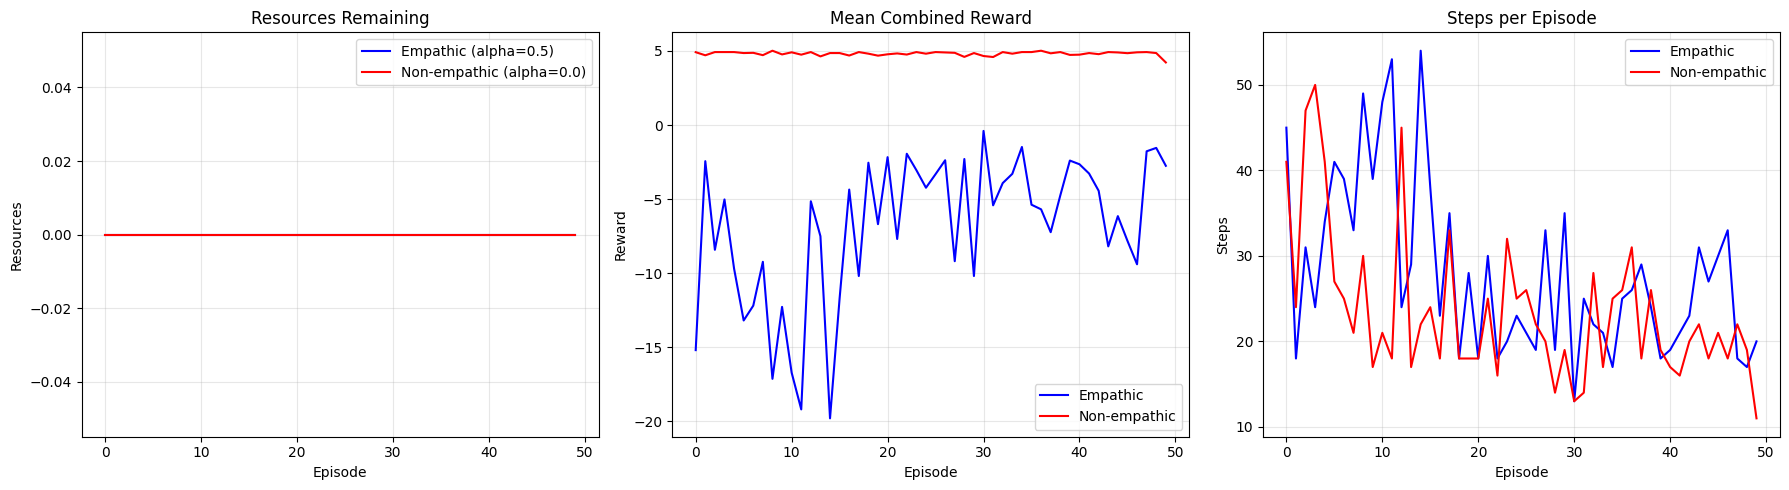

In [6]:
def run_simulation(alpha, see_emotions, num_episodes=50, max_steps=100, seed=42):
    np.random.seed(seed)
    env = GameTheoreticEnv(
        nb_agents=NB_AGENTS,
        initial_resources=INITIAL_RESOURCES,
        env_type='stochastic',
        emotion_type='average',
        see_emotions=see_emotions,
        alpha=alpha,
        beta=0.5,
        agent_class=DQNAgent,
        agent_configs=[{
            'learning_rate': 0.001,
            'gamma': 0.99,
            'epsilon': 1.0,
            'epsilon_decay': 0.995,
            'epsilon_min': 0.01,
            'batch_size': 16,
            'hidden_size': 64,
            'update_target_every': 5
        } for _ in range(NB_AGENTS)],
        smoothing='linear',
        threshold=0.5
    )

    resources_history = []
    combined_history = []
    steps_history = []

    for ep in range(num_episodes):
        obs = env.reset()
        total_combined = np.zeros(NB_AGENTS)

        for step in range(max_steps):
            actions = [agent.select_action(obs[i]) for i, agent in enumerate(env.agents)]
            next_obs, rewards, done, info = env.step(actions)
            total_combined += np.array(info['combined_reward'])

            for i, agent in enumerate(env.agents):
                agent.step(next_state=next_obs[i], reward=rewards[i], done=done)

            obs = next_obs
            if done:
                break

        resources_history.append(env.resource)
        combined_history.append(total_combined.mean())
        steps_history.append(step + 1)

    return resources_history, combined_history, steps_history


res_emp, comb_emp, steps_emp = run_simulation(alpha=0.5, see_emotions=True, seed=42)
res_non, comb_non, steps_non = run_simulation(alpha=0.0, see_emotions=False, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(res_emp, label='Empathic (alpha=0.5)', color='blue')
axes[0].plot(res_non, label='Non-empathic (alpha=0.0)', color='red')
axes[0].set_title('Resources Remaining')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Resources')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(comb_emp, label='Empathic', color='blue')
axes[1].plot(comb_non, label='Non-empathic', color='red')
axes[1].set_title('Mean Combined Reward')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps_emp, label='Empathic', color='blue')
axes[2].plot(steps_non, label='Non-empathic', color='red')
axes[2].set_title('Steps per Episode')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Steps')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test 5: Observation and Emotion Inspection

After running a few steps, inspect per-agent meal histories, emotion values, observations,
and verify that the combined reward formula holds:
`combined = (1 - alpha) * personal + alpha * empathic`

In [7]:
ALPHA = 0.5

env = GameTheoreticEnv(
    nb_agents=NB_AGENTS,
    initial_resources=INITIAL_RESOURCES,
    env_type='deterministic',
    emotion_type='average',
    see_emotions=True,
    alpha=ALPHA,
    beta=0.5,
    agent_class=DQNAgent,
    agent_configs=[{
        'learning_rate': 0.001,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_decay': 0.995,
        'epsilon_min': 0.01,
        'batch_size': 16,
        'hidden_size': 64,
        'update_target_every': 5
    } for _ in range(NB_AGENTS)],
    smoothing='linear',
    threshold=0.5
)

obs = env.reset()

for step in range(15):
    actions = [agent.select_action(obs[i]) for i, agent in enumerate(env.agents)]
    next_obs, rewards, done, info = env.step(actions)
    for i, agent in enumerate(env.agents):
        agent.step(next_state=next_obs[i], reward=rewards[i], done=done)
    obs = next_obs
    if done:
        break

print('=== Per-Agent Inspection After 15 Steps ===\n')
for i, agent in enumerate(env.agents):
    stats = env.get_agent_meal_stats(i)
    print(f'Agent {i}:')
    print(f'  Meal history (last 10): {stats["meal_history"]}')
    print(f'  Recent meals: {stats["recent_meals"]}')
    print(f'  Total meals: {stats["total_meals"]}')
    print()

print(f'Resource remaining: {env.resource}\n')

print('=== Observations ===')
current_obs = env.get_observations()
for i, o in enumerate(current_obs):
    print(f'  Agent {i} observation: {o}')

print('\n=== Reward Formula Verification ===')
actions = [1] * NB_AGENTS
_, rewards, _, info = env.step(actions)

personal = np.array(info['personal_reward'])
empathic = np.array(info['empathic_reward'])
combined = np.array(info['combined_reward'])
expected = (1 - ALPHA) * personal + ALPHA * empathic

print(f'  Personal rewards:  {personal}')
print(f'  Empathic rewards:  {empathic}')
print(f'  Combined rewards:  {combined}')
print(f'  Expected combined: {expected}')
print(f'  Match: {np.allclose(combined, expected)}')

=== Per-Agent Inspection After 15 Steps ===

Agent 0:
  Meal history (last 10): [True, False, False, True, True, False, False, False, True, True]
  Recent meals: 5
  Total meals: 6

Agent 1:
  Meal history (last 10): [False, False, True, False, True, False, False, False, True, False]
  Recent meals: 3
  Total meals: 5

Agent 2:
  Meal history (last 10): [True, False, False, True, False, True, True, True, False, False]
  Recent meals: 5
  Total meals: 6

Agent 3:
  Meal history (last 10): [False, False, False, True, True, True, False, False, False, False]
  Recent meals: 3
  Total meals: 3

Agent 4:
  Meal history (last 10): [False, False, True, False, True, False, False, False, False, True]
  Recent meals: 3
  Total meals: 4

Agent 5:
  Meal history (last 10): [True, True, True, True, False, False, False, True, True, True]
  Recent meals: 7
  Total meals: 8

Resource remaining: 0.0

=== Observations ===
  Agent 0 observation: [-0.16]
  Agent 1 observation: [-0.08]
  Agent 2 observation